In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')    # Use dark background for plots

import qibo
assert qibo.__version__ >= "0.2.20", "This script requires qibo version 0.2.20 or higher."

from qibo import Circuit, gates
from qibo.result import CircuitResult
from qibo.gates import *

from qibo.ui import plot_circuit, plot_density_hist, visualize_state
from qibo.ui.drawing_utils import QIBO_COMPLEMENTARY_COLOR, QIBO_DEFAULT_COLOR

### Import QEC module ###
from qibo_qec import QEC

custom_style = {                    # Define a custom style for the circuit plot
    "facecolor" : "#000000",
    "edgecolor" : "#ffffff",
    "linecolor" : "#ffffff",
    "textcolor" : "#ffffff",
    "fillcolor" : "#c41b1b",
    "gatecolor" : "#9000ff",
    "controlcolor" : "#360000"
}

In [2]:
from qibo.noise import NoiseModel, PauliError

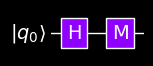

Initialized QEC with code type: bit_flip
Applying bit_flip code to a circuit with 5 qubit(s).


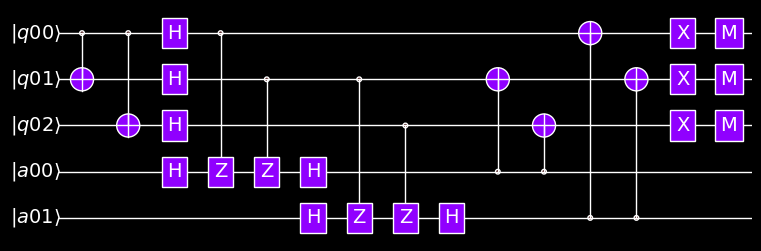

In [3]:
noise_model = NoiseModel()
noise_model.add(PauliError([("X", 0)]), gates.H)

qc = Circuit(1)
qc.add([gates.H(0)])
qc.add(gates.M(0))

plot_circuit(qc, style=custom_style)
plt.show()

qec = QEC(code_type="bit_flip")
qc_qec = qec.apply_code(qc)

plot_circuit(qc_qec, style=custom_style)
plt.show()

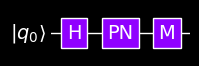

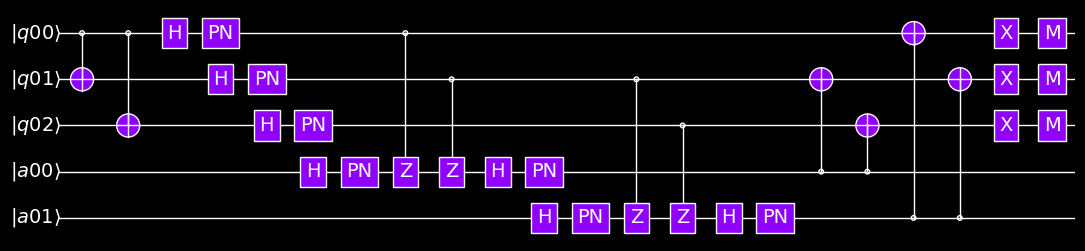

In [4]:
qc_noisy = noise_model.apply(qc)
plot_circuit(qc_noisy, style=custom_style)
plt.show()

qc_qec_noisy = noise_model.apply(circuit=qc_qec)
plot_circuit(qc_qec_noisy, style=custom_style)
plt.show()

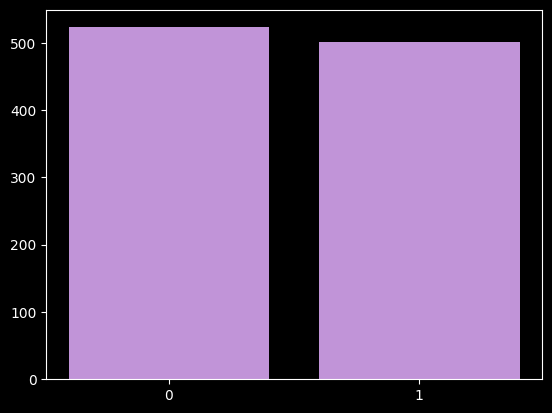

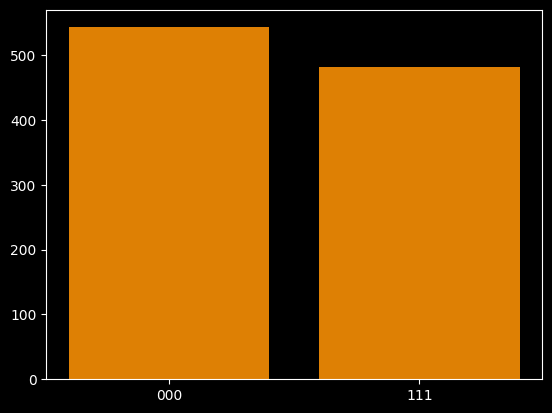

In [6]:
result = qc_noisy(nshots=2**10)

plt.bar(result.frequencies().keys(), result.frequencies().values(), color=QIBO_DEFAULT_COLOR)
plt.show()

result_qec = qc_qec_noisy(nshots=2**10)
plt.bar(result_qec.frequencies().keys(), result_qec.frequencies().values(), color=QIBO_COMPLEMENTARY_COLOR)
plt.show()